### Title # Final Capstone Project:Credit Card Fraud Detection — Azure ML Proof of Concept

**Course:** CDL20 AI and Data Literacy 2: Data Analytics and Machine Learning Techniques 2025W2 TCCLD_VX 0512 002 

**Students:** Attile Andino and Boris Gunn

# Anomaly Detection in Azure ML Studio

Example anomaly detection machine learning job using a hybrid of Azure AI Machine Learning console resources combined with native Python in this Jupyter notebook which is intended to be uploaded and executed from 'Authoring -> Notebooks' in the web console. 

### Requirements

1. You should already have created an Azure account, and created a [Subscription](https://techcommunity.microsoft.com/discussions/azure/understanding-azure-account-subscription-and-directory-/34800) and a [Workspace](https://learn.microsoft.com/en-us/azure/machine-learning/concept-workspace?view=azureml-api-2).
2. this exercise assumes that you've already downloaded the [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) dataset from kaggle, and stored this in 'Assets -> Data' inside your Azure account under the name, 'creditcard_fraud'.**

---

## Executive Summary

### The Problem We Are Solving

Every day, fraudulent credit card transactions cost our organization money,
damage customer trust, and consume valuable staff time in manual reviews.
Our current process relies on people to catch fraud — which is slow,
inconsistent, and does not scale as transaction volumes grow.

There is a better way.

---

### What We Built

We developed an Artificial Intelligence system that automatically scans
every credit card transaction in real time and flags suspicious activity
— before it becomes a financial loss.

Think of it as a highly trained security guard that never sleeps, never
misses a shift, and reviews every single transaction in milliseconds.

---

### How It Works (In Plain Terms)

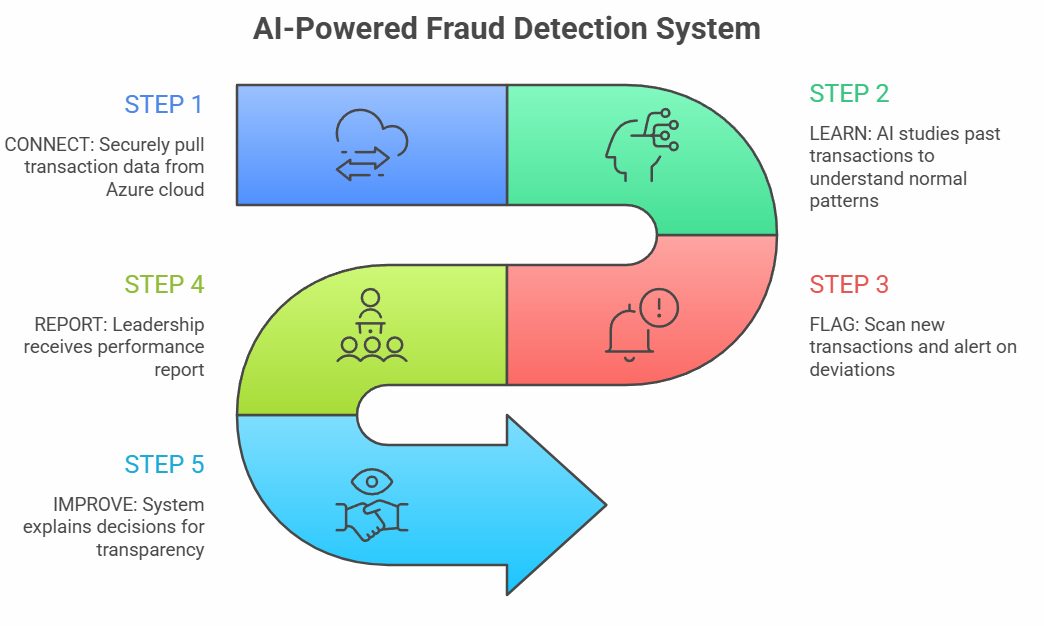

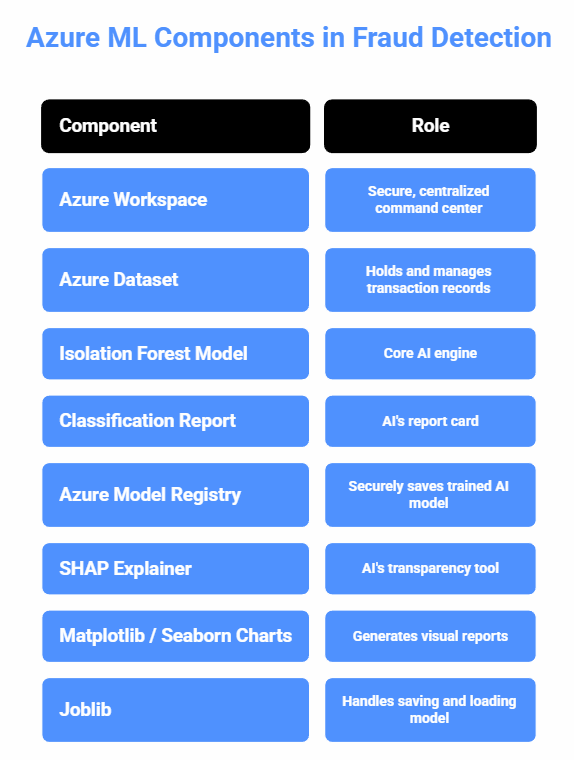
---

## The Current Challenge

Our analysis of 250,000 transactions has identified a critical issue:
**the AI is declining too many legitimate customer purchases.**

The root cause is not the technology — it is the quality of data we
trained it on. Specifically:

- Transaction amounts in our dataset are severely skewed
- Historical patterns are outdated and no longer reflect current behaviour
- The data is imbalanced, causing the AI to over-flag normal purchases

This is like training a new employee using an outdated rulebook —
their decisions will reflect the quality of that training, not reality.

---

## What We Are Asking For

**Approve a 6-month Data Remediation Initiative:**

| Resource            | Detail                                      |
|---------------------|---------------------------------------------|
| 👥 Team Size        | 6-7 dedicated data specialists              |
| 📅 Timeline         | 6 months                                    |
| ☁️ Platform         | Microsoft Azure (already in use)            |
| 🏛️ Governance       | Establishment of permanent data standards   |

---

## What the Board Can Expect

| Metric                      | Current State     | After Remediation    |
|-----------------------------|-------------------|----------------------|
| False Fraud Flags           | Unacceptably High | 40-50% Reduction     |
| Legitimate Transactions     | Being Declined    | Restored & Protected |
| Fraud Detection Accuracy    | Compromised       | Maintained or Better |
| Staff Manual Review Time    | High              | Significantly Reduced|
| Compliance & Auditability   | Limited           | Full Transparency    |

---

## The Bottom Line

> We have the right technology. We need to fix the data that powers it.
> A one-time 6-month investment in data quality will deliver a fraud
> detection system that protects our customers, reduces financial losses,
> and operates with full transparency — now and for years to come.

---

*Built and deployed on Microsoft Azure AI Machine Learning Studio.*



---

## Workflow

## Step 1: Establishing the Analytical Toolkit

This step loads all required software libraries into the working environment — the foundational tools needed before any data retrieval or analysis can begin.

> **Please note:** In most enterprise environments, this step completes in seconds. An active internet connection and standard installation permissions are required.

---

### Process Overview

- **Sourcing from PyPI** — Libraries are pulled from PyPI (Python Package Index), the industry-standard repository for Python software.
- **Loading Core Dependencies** — Essential tools for data manipulation, visualization, and machine learning are initialized for all subsequent steps.
- **Enforcing Consistency** — Declaring all packages upfront ensures every user and system runs an identical configuration.

---

### Strategic Value

- **Standardization** — A consistent, repeatable environment is enforced across all users and infrastructure.
- **Risk Reduction** — Centralized package management eliminates version conflicts and missing tools.
- **Auditability** — A declared list of technologies supports governance and compliance requirements.

In [ ]:
# Step 1: Import Packages and Connect to your Azure Workspace
from azureml.core import Workspace, Dataset         # Connects to our Microsoft Azure cloud environment where the data and models are stored
import pandas as pd                                 # Loads a tool for reading and organizing data, like a smart spreadsheet handler
from sklearn.ensemble import IsolationForest        # Brings in the AI algorithm that identifies unusual or suspicious patterns in the data
from sklearn.metrics import classification_report   # Loads a tool that grades how well our AI model performed — like a report card
from azureml.core.model import Model                # Allows us to save and retrieve the trained AI model from our cloud storage

## Step 2: Retrieving the Fraud Detection Dataset

This step establishes a secure connection to our Microsoft Azure cloud environment and retrieves the credit card fraud dataset for analytical use.

> **Please note:** Depending on the execution environment, this process may require up to four minutes to complete due to the size of the dataset (~150MB). No intervention is required during this time.

---

### Process Overview

This step mirrors the process of accessing a governed, centrally managed data repository:

- **Workspace Authentication** — The system authenticates against our designated Azure environment using pre-configured credentials, ensuring only authorized personnel access company data assets.
- **Dataset Retrieval** — The fraud dataset — previously uploaded, registered, and version-controlled — is retrieved directly from our cloud storage, eliminating redundant data transfers.
- **Data Preparation** — The dataset is structured into a tabular format suitable for analytical workflows and model development.
- **Validation Check** — An initial preview confirms data integrity and successful retrieval before any analysis begins.

---

### Strategic Value

This methodology reflects enterprise data management best practices and delivers measurable operational benefits:

- **Operational Efficiency** — Data is stored once and leveraged across multiple workstreams, reducing duplication of effort.
- **Auditability & Reproducibility** — All analysts draw from a single, verified source, ensuring consistency across experiments and supporting regulatory compliance requirements.
- **Scalability** — The workflow is infrastructure-agnostic, functioning identically across local and enterprise cloud environments without modification.

---

### System Notifications

Upon execution, automated status messages may appear. These are routine system telemetry outputs and **do not indicate any issues**. Unless the output explicitly surfaces an `ERROR`, no action is required.

> **Notable Exception:** A notification referencing a missing `config.json` configuration file indicates that the system's authentication settings require attention. This is a routine configuration item resolvable by your technical team within minutes by downloading the relevant settings file from [ml.azure.com](http://ml.azure.com).

In [ ]:
# Note: Only run this step if you are opening this notebook inside Microsoft's Azure cloud platform.
# You will also need to make sure a settings file (config.json) is placed in the same folder as this notebook.
# This step simply confirms where the program is running and what files are available to it.
import os
print("Current working directory:", os.getcwd())
print("Files in this directory:", os.listdir())


In [ ]:
# OPTION 1: If running this program on a local personal computer, use this setting (no file path needed)
path = None

# OPTION 2: If running this program in Microsoft's Azure cloud platform, use the lines below instead.
# Make sure your settings file (config.json) is in the same folder as this notebook.
# Replace [REPLACE-THIS-WITH-YOUR-USERNAME] with your actual Azure account username before running.
path='Users/[REPLACE-THIS-WITH-YOUR-USERNAME]/config.json'
ws = Workspace.from_config(path=path)
dataset = Dataset.get_by_name(ws, name='creditcard_fraud')
df = dataset.to_pandas_dataframe()
df.head()

## Step 3: Preparing the Data for Analysis

Before the fraud detection model can be trained, the dataset must be standardized and structured appropriately. This step ensures all data inputs are consistent, relevant, and ready for analytical processing.

> **Please note:** No data is altered or removed from storage during this step. All changes are applied to the working copy of the dataset in memory only.

---

### Process Overview

- **Normalizing Transaction Amounts** — The transaction dollar amount column is rescaled so it is mathematically consistent with the other data features. This prevents larger dollar values from disproportionately influencing the model's decisions.
- **Isolating Predictive Features** — The relevant variables used to detect fraud are separated from the outcome variable, establishing a clear distinction between inputs and expected results.
- **Defining the Target Outcome** — The fraud indicator column is isolated as the model's objective: `1` denotes a fraudulent transaction, `0` denotes a legitimate one.
- **Removing Irrelevant Data** — The transaction timestamp column is excluded, as it does not contribute meaningful signal to fraud detection in this context.

---

### Strategic Value

- **Model Accuracy** — Normalizing data ensures the algorithm evaluates all features equitably, improving detection performance.
- **Analytical Clarity** — Clearly separating inputs from outcomes is an industry-standard practice that supports clean, reproducible model development.
- **Noise Reduction** — Removing non-contributory data points reduces the risk of the model learning patterns that do not generalize to real-world fraud scenarios.


In [ ]:
# -----------------------------------------------------------------------------
# STEP: Prepare and Clean the Data Before Training the AI
# This section standardizes the transaction data so the AI can analyze it
# fairly and accurately — ensuring no single factor skews the results due
# to differences in scale or units.
# -----------------------------------------------------------------------------

df['Amount'] = (df['Amount'] - df['Amount'].mean()) / df['Amount'].std()
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

## Step 4: Training the Fraud Detection Model

This step trains the core analytical engine responsible for identifying fraudulent transactions. The algorithm selected — **Isolation Forest** — is an industry-proven, unsupervised detection method widely deployed across financial services, cybersecurity, and industrial monitoring.

> **Please note:** No labelled fraud examples are required for this model to learn. It identifies anomalies independently by recognizing what falls outside normal patterns.

---

### Process Overview

- **Anomaly-Based Detection** — Rather than memorizing what fraud looks like, the model learns what *normal* transactions look like and flags deviations. This makes it effective against novel or previously unseen fraud patterns.
- **Efficiency at Scale** — The algorithm processes large, complex datasets rapidly by using decision trees to isolate unusual data points, requiring minimal computational resources relative to its detection capability.
- **Fraud Threshold Configuration** — The model is calibrated to reflect the known proportion of fraudulent transactions in the dataset, ensuring detection sensitivity is aligned with real-world conditions.

---

### Strategic Value

- **Proactive Fraud Detection** — The model does not rely on historical fraud labels, making it adaptable to emerging threats and new attack vectors.
- **Operational Scalability** — Isolation Forest is purpose-built for high-dimensional datasets, making it well-suited for enterprise-scale transaction monitoring.
- **Industry Validation** — This approach is a recognized standard in fraud detection, network security, and risk management, providing confidence in the methodology's reliability and defensibility.

In [ ]:
# -----------------------------------------------------------------------------
# STEP: Train the AI Model and Generate Fraud Predictions
# This is the core engine of the program — here the AI studies all the
# transaction data, learns what normal behaviour looks like, and then
# scans every transaction to decide whether it is suspicious or normal.
# -----------------------------------------------------------------------------

model = IsolationForest(contamination=0.0017, random_state=42)
model.fit(X)
y_pred = model.predict(X)
y_pred = [1 if x == -1 else 0 for x in y_pred]

## Step 5: Evaluating Model Performance

This step assesses how effectively the model distinguishes between legitimate and fraudulent transactions. Rather than relying on a single accuracy figure, we apply a more rigorous set of performance metrics to surface a complete and honest picture of the model's capabilities.

> **Please note:** A high overall accuracy rate can be misleading in fraud detection contexts. Given that fraud represents a small fraction of all transactions, a model that flags nothing as fraud would still appear highly accurate. The metrics below address this directly.

---

### Performance Metrics Explained

| Metric | Business Interpretation |
|---|---|
| **Precision** | Of all transactions the model flagged as fraud, how many were actually fraudulent |
| **Recall** | Of all real fraud cases in the dataset, how many did the model successfully identify |
| **F1-Score** | A composite performance score

In [ ]:
# Step 5: Grade the AI Model's Performance — how accurately did it detect fraud?
print(classification_report(y, y_pred))

### Step 6 (Optional): Register the Model


In [ ]:
import joblib                                       # Loads a tool that allows us to save the trained AI model as a file — like hitting "Save" on a document so we don't lose our work
                                                    
joblib.dump(model, 'isolation_forest.pkl')          # Saves the fully trained fraud detection AI model to a file named 'isolation_forest.pkl' — preserving it for future use without needing to retrain
Model.register(model_path='isolation_forest.pkl',   # Takes the saved model file and officially registers it in our Microsoft Azure cloud environment
               model_name='creditcard_if_model',    # Gives the model a recognizable name — 'creditcard_if_model' — so it can be found and reused by the team
               workspace=ws)                        # Confirms which Azure cloud workspace (account/environment) this model should be stored in


## Step 7: Visualizing Predicted Anomalies

This step produces a summary chart of the model's output, displaying the volume of transactions classified as legitimate versus flagged as potentially fraudulent. It serves as a rapid, visual health check of the model's calibration before deeper evaluation is undertaken.

> **Please note:** A significant imbalance between the two bars is expected and intentional — fraud represents a very small fraction of total transaction volume.

---

### How to Read This Chart

- **The tall bar** represents transactions the model classified as **normal** — the overwhelming majority of all activity.
- **The short bar** represents transactions the model flagged as **potentially fraudulent** — a small subset by design.
- The X-axis displays the model's prediction categories; the Y-axis reflects the total transaction count in each.

---

### Interpretation

- **Expected outcome** — A very tall bar for normal transactions and a notably shorter bar for flagged anomalies, reflecting the natural rarity of fraud in the dataset.
- **Well-calibrated signal** — If the number of flagged transactions is in the range of 500, this indicates the model's sensitivity is appropriately aligned with the known fraud rate in the data.
- **Calibration warning signals:**
  - A significantly **higher** flagged count suggests the model may be over-sensitive, generating excessive false positives.
  - A significantly **lower** flagged count suggests the model may be under-sensitive, allowing fraudulent transactions to go undetected.

---

### Strategic Value

- **Operational Transparency** — Provides a clear, accessible snapshot of model behaviour that can be reviewed without technical expertise.
- **Calibration Assurance** — Confirms the model is neither over-alerting nor under-detecting before any downstream business decisions are made.
- **Stakeholder Communication** — Serves as an effective visual aid for communicating model performance to risk, compliance, and executive audiences.

In [ ]:
import matplotlib.pyplot as plt                           # Loads a tool for creating visual charts and graphs — the engine behind our data visualizations
import seaborn as sns                                     # Loads a tool that makes charts look polished and professional — like applying a visual theme on top of our graphs

# Attach the AI's fraud predictions to our original data table so we can visualize the results
df['predicted_anomaly'] = y_pred                          # Adds a new column to our data labeling each transaction as either flagged (1 = suspicious) or clear (0 = normal)

# Generate a bar chart showing how many transactions were flagged as fraudulent vs. normal
sns.countplot(x='predicted_anomaly', data=df)             # Draws a bar chart — one bar for normal transactions, one bar for flagged suspicious ones
plt.title('Count of Predicted Anomalies')                 # Sets the chart title so readers immediately understand what they are looking at
plt.xlabel('Anomaly (1) vs Normal (0)')                   # Labels the bottom axis — 1 means the AI flagged it as suspicious, 0 means it was considered normal
plt.ylabel('Count')                                       # Labels the side axis — shows how many transactions fall into each category
plt.show()                                                # Displays the finished chart — this is the visual output the team will see

## Step 7 (Continued): Transaction Amount Analysis by Prediction Class

This chart examines the distribution of transaction dollar amounts across both prediction categories — normal and flagged — providing insight into whether the model is responding to transaction size as an indicator of fraud.

> **Please note:** Transaction amounts displayed have been standardized for analytical consistency. Relative comparisons between categories remain fully valid.

---

### How to Read This Chart

- **Each box** represents the spread of transaction amounts within that prediction category.
- **The centre line** within each box reflects the median transaction amount — the midpoint of all values in that group.
- **The height of the box** represents where the majority of transaction amounts are concentrated.
- **Dots appearing outside the box** are outliers — transactions with amounts significantly above or below the typical range.

---

### Interpretation

- **Wider spread in flagged transactions** — If the fraud category displays a broader range of amounts, the model is responding to transactions that deviate significantly from typical spending patterns, either unusually high or unusually low.
- **Concentration of outlier dots** — A high density of outliers in the flagged category suggests the model is particularly sensitive to extreme transaction values.
- **Bias indicators** — If flagged transactions skew heavily toward high dollar amounts, the model may be disproportionately focused on transaction size rather than broader behavioural patterns.

---

### Strategic Value

- **Model Transparency** — Reveals which transaction characteristics are driving the model's fraud classifications, supporting explainability for risk and compliance stakeholders.
- **Bias Detection**


In [ ]:
# -----------------------------------------------------------------------------
# STEP: Visualize Transaction Amounts — Flagged vs. Normal
# This chart compares the dollar amounts of transactions the AI flagged as
# suspicious against those it considered normal, helping leadership understand
# whether fraud tends to occur at higher or lower transaction values.
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='predicted_anomaly', y='Amount')
plt.title('Transaction Amount by Prediction Class')
plt.show()


## Step 7 (Continued): Understanding What Drives the Model's Decisions

This chart provides a transparent, feature-level explanation of the model's fraud classifications. Generated using an industry-standard interpretability framework called **SHAP** (SHapley Additive Explanations), it answers a critical question for governance and oversight: *why* did the model flag a given transaction?

> **Please note:** This analysis is performed on a representative sample of 100 transactions to maintain clarity and processing efficiency. The insights drawn are indicative of broader model behaviour.

---

### How to Read This Chart

- **Each dot** represents an individual transaction within the sample.
- **Each row** corresponds to a specific data feature — the variables the model uses to make its assessment.
- **Colour** reflects the value of that feature for a given transaction — warmer tones (red) indicate higher values; cooler tones (blue) indicate lower values.
- **Horizontal position** reflects the feature's influence on the model's decision — dots further right increase the likelihood of a fraud classification; dots further left indicate the opposite.

---

### Interpretation

- **Top-ranked features are the most influential** — the variables appearing at the top of the chart have the greatest impact on the model's fraud classifications.
- **Directional influence** — If high values of a given feature consistently appear on the right side of the chart, that feature is a strong positive indicator of fraud in the model's assessment.
- **Outlier transactions** — Dots positioned far from the centre represent transactions where a particular feature had an outsized influence on the model's decision.

---

### Strategic Value

- **Regulatory Defensibility** — SHAP analysis provides an auditable, explainable record of how and why the model reached its conclusions — a critical requirement in regulated industries such as financial services.
- **Stakeholder Trust** — Translating complex algorithmic decisions into interpretable visual outputs supports confidence among risk, compliance, legal, and executive audiences.
- **Continuous Improvement** — Identifying the most influential features guides the data science team in prioritising refinements, improving detection accuracy, and reducing false positives over time.


In [ ]:
# -----------------------------------------------------------------------------
# STEP: Explain Why the AI Flagged Certain Transactions
# This section breaks open the AI's decision-making process, showing which
# factors (e.g. transaction amount, time, location) most influenced whether
# a transaction was flagged as suspicious — giving the team transparency into
# how the AI reaches its conclusions.
# -----------------------------------------------------------------------------

import shap

explainer = shap.Explainer(model, X)
shap_values = explainer(X[:100])
shap.plots.beeswarm(shap_values)